In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *

In [2]:
OII_rest    = lines_vac['OII']
NII_rest    = lines_vac['NII']
Hbeta_rest  = lines_vac['Hbeta']
Halpha_rest = lines_vac['Halpha']
SII_rest    = lines_vac['SII']
CaII_rest   = lines_vac['CaII']
NaD_rest    = lines_vac['NaD']

In [3]:
spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectra = Spectrum(spectra_data, color_data)

blue_crit = (spectra.color_criteria(criterion='g-z<1.25', exclude=False)) | (spectra.color_criteria(criterion='g-r<0.75', exclude=False))
qso_crit = spectra.subtype_criteria(subtype='QSO', exclude=True)
spectra.subset(criteria=blue_crit & qso_crit)
spectra.shrink_dataset(5)

Plot = PlotSpectrum(spectra)
Fit = FitSpectrum(spectra)

In [4]:
Fit.shift_to_rest_frame()

In [5]:
example_i = 0
print("Example spectrum ID:", spectra.targetID[example_i])

Example spectrum ID: 39627806174347647


In [6]:
params_s, status_s = Fit.fit_flux(id=spectra.targetID[example_i], lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=True)
params_d, status_d = Fit.fit_flux(id=spectra.targetID[example_i], lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=True)
print("Fitting status:", status_s)
print("Fitting parameters:", params_s)
print("Fitting status:", status_d)
print("Fitting parameters:", params_d)

Fitting status: True
Fitting parameters: {'dz': np.float64(-2.8768448789089757e-06), 'sigma': np.float64(2.538333947026558), 'conti_params': (np.float64(0.0004300602801299299), np.float64(8.176914889282574e-12)), 'free_comps': [(np.float64(21.337620674752007), np.float64(6564.613113105029), np.float64(2.538333947026558)), (np.float64(3.2188101848179396), np.float64(6549.840185183216), np.float64(2.538333947026558)), (np.float64(8.29860123203962), np.float64(6585.259603175244), np.float64(2.538333947026558)), (np.float64(4.4623225474485295), np.float64(6718.274985223091), np.float64(2.538333947026558)), (np.float64(2.8441963665277994), np.float64(6732.648809883336), np.float64(2.538333947026558))], 'fixed_comps': None, 'gaussian_params': [(np.float64(21.337620674752007), np.float64(6564.613113105029), np.float64(2.538333947026558)), (np.float64(3.2188101848179396), np.float64(6549.840185183216), np.float64(2.538333947026558)), (np.float64(8.29860123203962), np.float64(6585.259603175244)

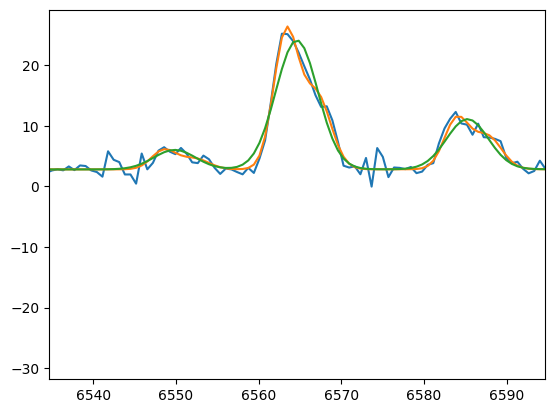

In [7]:
fitted_model_s = model(Fit.data_stack[example_i, 0, :], gaussian_parms=params_s['gaussian_params'], conti_parms=params_s['conti_params'])
fitted_model_d = model(Fit.data_stack[example_i, 0, :], gaussian_parms=params_d['gaussian_params'], conti_parms=params_d['conti_params'])
crop_region = [lines_vac['Halpha'][0]-30, lines_vac['Halpha'][0]+30]
# crop_region = [6500, 6750]
plt.plot(Fit.data_stack[example_i, 0, :], Fit.data_stack[example_i, 1, :])
plt.plot(Fit.data_stack[example_i, 0, :], fitted_model_d)
plt.plot(Fit.data_stack[example_i, 0, :], fitted_model_s)
plt.xlim(crop_region)
plt.show()

In [8]:
print(Fit.calculate_chisq(spectra.targetID[example_i], params=params_d, region=crop_region))
print(Fit.calculate_chisq(spectra.targetID[example_i], params=params_s, region=crop_region))

107.73763918335642
328.76424166985544


In [ ]:
print(Fit.calculate_f_test(spectra.targetID[example_i], params_s=params_s, params_d=params_d, region=crop_region))

(np.float64(39.491881668429876), np.float64(1.1102230246251565e-16))


: 